# **Day-11 | House price prediction using Linear Regression-SingleVariable**

### *Import Libraries*

In [39]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

### *Load Dataset from Local Directory*

In [40]:
from google.colab import files
uploaded = files.upload()

Saving Housing.csv to Housing (1).csv


### *Load Dataset*

In [41]:
dataset = pd.read_csv('Housing.csv')

### *Load Summarize*

In [42]:
print(dataset.shape)
print(dataset.head(5))

(545, 13)
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


### *Visualize Dataset*

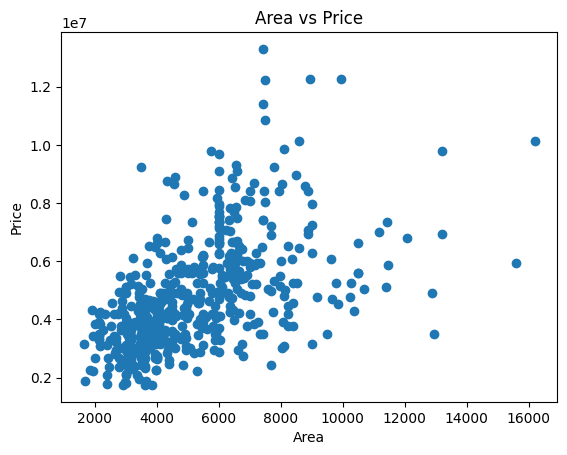

In [43]:
plt.scatter(dataset.area, dataset.price)
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

### *Segregate Dataset into Input X & Output Y*

In [44]:
X = dataset[['area']]
# The rest of the original code for categorical variable handling is now unnecessary
# as X will only contain 'area'
# If you intend to use multiple features, please adjust this cell accordingly.

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Convert 'yes'/'no' columns to 1/0
for col in ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']:
    if col in categorical_cols:
        X[col] = X[col].apply(lambda x: 1 if x == 'yes' else 0)

# Apply one-hot encoding to 'furnishingstatus'
if 'furnishingstatus' in categorical_cols:
    X = pd.get_dummies(X, columns=['furnishingstatus'], drop_first=True)

X

,area
0,7420
1,8960
2,9960
3,7500
4,7420
...,...
540,3000
541,2400
542,3620
543,2910


In [45]:
Y = dataset.price
Y

,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000
...,...
540,1820000
541,1767150
542,1750000
543,1750000


# *Train/Test Split*

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

### *Training Dataset using Linear Regression*

In [47]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, Y_train)  # train on train set

LinearRegression()

### *Predicted Price for Land sq.Feet of custom values*

In [48]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Generate predictions
predictions = model.predict(X_test)

# Evaluate model
r2 = r2_score(Y_test, predictions)
mae = mean_absolute_error(Y_test, predictions)
mse = mean_squared_error(Y_test, predictions)
rmse = np.sqrt(mse)

print("R² Score:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

R² Score: 0.27287851871974644
MAE: 1474748.1337969352
MSE: 3675286604768.185
RMSE: 1917103.7021424233


### Let's check is our model is Right ?
### Theory Calculation
### Y = m * X + b (m is coefficient and b is intercept)

*Coefficient - m*

In [49]:
m=model.coef_
print(m)

[425.72984194]


*Intercept - b*

In [50]:
b=model.intercept_
print(b)

2512254.2639593435


### Y=mx+b
*x is Independant variable - Input - area*

In [51]:
# Define the custom area value for prediction
x = 40000
manual_predicted_price = m * x + b
print(f"The Price of {x} Square feet Land (Manual Calculation) is: {manual_predicted_price[0]:,.2f}")
import pandas as pd
area_for_prediction = pd.DataFrame({'area': [x]})
model_predicted_price = model.predict(area_for_prediction)
print(f"The Price of {x} Square feet Land (Model Prediction) is: {model_predicted_price[0]:,.2f}")

The Price of 40000 Square feet Land (Manual Calculation) is: 19,541,447.94
The Price of 40000 Square feet Land (Model Prediction) is: 19,541,447.94
